In [36]:
import pandas as pd
import numpy as np
import plotly.express as px
from dash import Dash, html, dcc
import plotly.graph_objects as go
from dash.dependencies import Input,Output

In [2]:
url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/spacex_launch_dash.csv"

In [19]:
spacex_df = pd.read_csv(url)

In [13]:
option_list = df["Launch Site"].unique().tolist()

In [16]:
option_list.insert(0,"All Sites")

In [95]:
app = Dash()

app.layout = html.Div(children = [
    html.H1("SpaceX Launch Records Dashboard",style={"textAling":"center","color":"#503D36","font-size":35}),
    html.Div(["Selected Sites:",dcc.Dropdown(option_list,"All Sites",id="site-dropdown")]),
    html.Br(),
    html.Div(dcc.Graph(id = "success-pie-chart")),
    html.Div(["Payload Range (Kg):",
              dcc.RangeSlider(0,10000,value = [spacex_df["Payload Mass (kg)"].min(),spacex_df["Payload Mass (kg)"].max()],step=1000,id="payload-slider")],
            style={"height":"30px","font-size":16}),
    html.Br(),
    html.Br(),
    html.Div(dcc.Graph(id="success-payload-scatter-chart"))
])

@app.callback(
    Output(component_id="success-pie-chart",component_property="figure"),
    Input(component_id="site-dropdown",component_property="value")
)

def get_pie_chart(entered_site):

    if entered_site == "All Sites":

        group_df = spacex_df.groupby("Launch Site")["class"].sum().rename("sum").to_frame().reset_index()
        fig_pie = px.pie(group_df,values="sum",names="Launch Site")

    else:
        
        filtered_df = spacex_df[spacex_df["Launch Site"] == entered_site]
        filtered_df = filtered_df["class"].value_counts().to_frame().reset_index()
        filtered_df["Class_names"] = filtered_df["class"].map({0:"Failure",1:"Success"})
        fig_pie = px.pie(filtered_df, values = "count",names="Class_names",color="class",color_discrete_map = {0:"red",1:"green"})
        
    return fig_pie

@app.callback(
    Output(component_id="success-payload-scatter-chart",component_property="figure"),
    [Input(component_id="site-dropdown",component_property="value"),
     Input(component_id="payload-slider",component_property="value")]
)

def get_scatter_plot(entered_site,entered_payload):

    
    if entered_site == "All Sites":

        filtered_df = spacex_df[(spacex_df["Payload Mass (kg)"] >= min(entered_payload)) & (spacex_df["Payload Mass (kg)"] <= max(entered_payload))]
        fig_scatter = px.scatter(filtered_df, x = "Payload Mass (kg)", y = "class",color = "Launch Site")
        
    else:
        
        filtered_df = spacex_df[spacex_df["Launch Site"] == entered_site]
        filtered_df = filtered_df[(filtered_df["Payload Mass (kg)"] >= min(entered_payload)) & (filtered_df["Payload Mass (kg)"] <= max(entered_payload))]
        fig_scatter = px.scatter(filtered_df, x = "Payload Mass (kg)", y = "class")
    
    return fig_scatter

if __name__ == '__main__':
    app.run()

In [10]:
df.head()

,Unnamed: 0,Flight Number,Launch Site,class,Payload Mass (kg),Booster Version,Booster Version Category
0,0,1,CCAFS LC-40,0,0.0,F9 v1.0 B0003,v1.0
1,1,2,CCAFS LC-40,0,0.0,F9 v1.0 B0004,v1.0
2,2,3,CCAFS LC-40,0,525.0,F9 v1.0 B0005,v1.0
3,3,4,CCAFS LC-40,0,500.0,F9 v1.0 B0006,v1.0
4,4,5,CCAFS LC-40,0,677.0,F9 v1.0 B0007,v1.0


In [20]:
filtered = spacex_df[spacex_df["Launch Site"] == "CCAFS LC-40"]

In [21]:
filtered

,Unnamed: 0,Flight Number,Launch Site,class,Payload Mass (kg),Booster Version,Booster Version Category
0,0,1,CCAFS LC-40,0,0.0,F9 v1.0 B0003,v1.0
1,1,2,CCAFS LC-40,0,0.0,F9 v1.0 B0004,v1.0
2,2,3,CCAFS LC-40,0,525.0,F9 v1.0 B0005,v1.0
3,3,4,CCAFS LC-40,0,500.0,F9 v1.0 B0006,v1.0
4,4,5,CCAFS LC-40,0,677.0,F9 v1.0 B0007,v1.0
5,5,7,CCAFS LC-40,0,3170.0,F9 v1.1,v1.1
6,6,8,CCAFS LC-40,0,3325.0,F9 v1.1,v1.1
7,7,9,CCAFS LC-40,0,2296.0,F9 v1.1,v1.1
8,8,10,CCAFS LC-40,0,1316.0,F9 v1.1,v1.1
9,9,11,CCAFS LC-40,0,4535.0,F9 v1.1,v1.1


In [58]:
filtered_ratio = filtered["class"].value_counts().to_frame().reset_index()

In [59]:
filtered_ratio

,class,count
0,0,19
1,1,7


In [60]:
filtered_ratio["Class_names"] = filtered_ratio["class"].map({0:"Failure",1:"Success"})

In [61]:
filtered_ratio

,class,count,Class_names
0,0,19,Failure
1,1,7,Success


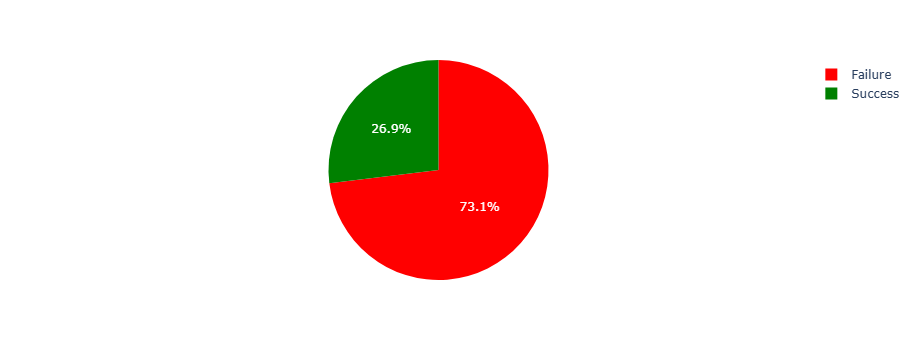

In [63]:
fig = px.pie(filtered_ratio, values = "count",names="Class_names",color="Class_names",color_discrete_map = {"Failure":"red","Success":"green"})
fig.show()

In [48]:
group_df = spacex_df.groupby("Launch Site")["class"].sum().rename("sum").to_frame().reset_index()

In [49]:
group_df

,Launch Site,sum
0,CCAFS LC-40,7
1,CCAFS SLC-40,3
2,KSC LC-39A,10
3,VAFB SLC-4E,4


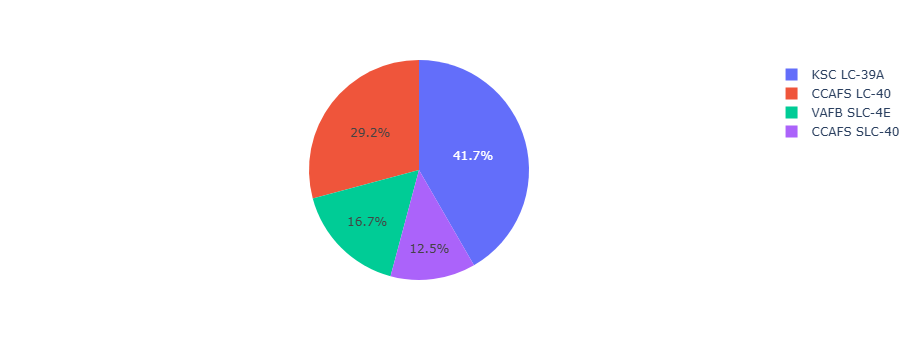

In [50]:
fig1 = px.pie(group_df,values="sum",names="Launch Site")
fig1.show()

In [66]:
spacex_df[["Payload Mass (kg)"]].describe()

,Payload Mass (kg)
count,56.000000
mean,3696.648214
std,2568.509679
min,0.000000
25%,2121.000000
50%,3412.500000
75%,5042.500000
max,9600.000000


In [65]:
spacex_df.head()

,Unnamed: 0,Flight Number,Launch Site,class,Payload Mass (kg),Booster Version,Booster Version Category
0,0,1,CCAFS LC-40,0,0.0,F9 v1.0 B0003,v1.0
1,1,2,CCAFS LC-40,0,0.0,F9 v1.0 B0004,v1.0
2,2,3,CCAFS LC-40,0,525.0,F9 v1.0 B0005,v1.0
3,3,4,CCAFS LC-40,0,500.0,F9 v1.0 B0006,v1.0
4,4,5,CCAFS LC-40,0,677.0,F9 v1.0 B0007,v1.0


In [67]:
spacex_df["Payload Mass (kg)"].min()

np.float64(0.0)

In [81]:
scatter_df = spacex_df[spacex_df["Launch Site"] == "CCAFS LC-40"]

In [82]:
scatter_df

,Unnamed: 0,Flight Number,Launch Site,class,Payload Mass (kg),Booster Version,Booster Version Category
0,0,1,CCAFS LC-40,0,0.0,F9 v1.0 B0003,v1.0
1,1,2,CCAFS LC-40,0,0.0,F9 v1.0 B0004,v1.0
2,2,3,CCAFS LC-40,0,525.0,F9 v1.0 B0005,v1.0
3,3,4,CCAFS LC-40,0,500.0,F9 v1.0 B0006,v1.0
4,4,5,CCAFS LC-40,0,677.0,F9 v1.0 B0007,v1.0
5,5,7,CCAFS LC-40,0,3170.0,F9 v1.1,v1.1
6,6,8,CCAFS LC-40,0,3325.0,F9 v1.1,v1.1
7,7,9,CCAFS LC-40,0,2296.0,F9 v1.1,v1.1
8,8,10,CCAFS LC-40,0,1316.0,F9 v1.1,v1.1
9,9,11,CCAFS LC-40,0,4535.0,F9 v1.1,v1.1


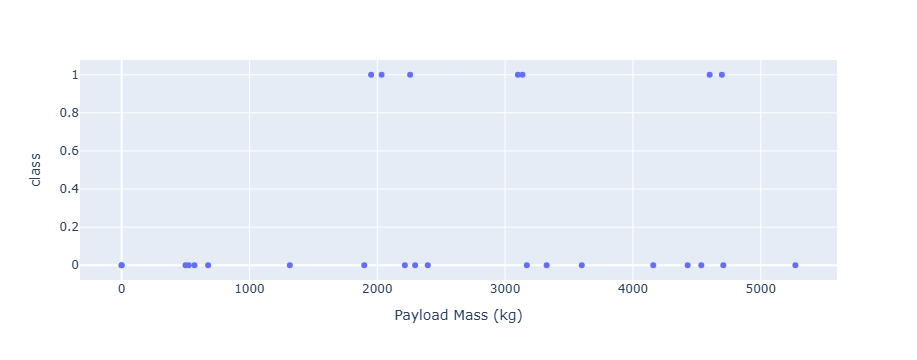

In [83]:
fig2 = px.scatter(scatter_df, x = "Payload Mass (kg)", y="class")
fig2.show()

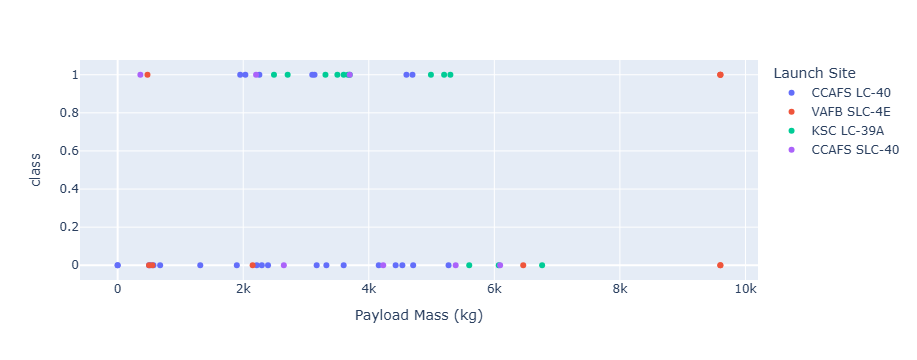

In [84]:
fig3 = px.scatter(spacex_df, x = "Payload Mass (kg)", y="class", color = "Launch Site")
fig3.show()

In [92]:
df_filtradasso = spacex_df[(spacex_df["Payload Mass (kg)"]>= 1000) & (spacex_df["Payload Mass (kg)"] <=8000)]

In [93]:
df_filtradasso

,Unnamed: 0,Flight Number,Launch Site,class,Payload Mass (kg),Booster Version,Booster Version Category
5,5,7,CCAFS LC-40,0,3170.00,F9 v1.1,v1.1
6,6,8,CCAFS LC-40,0,3325.00,F9 v1.1,v1.1
7,7,9,CCAFS LC-40,0,2296.00,F9 v1.1,v1.1
8,8,10,CCAFS LC-40,0,1316.00,F9 v1.1,v1.1
9,9,11,CCAFS LC-40,0,4535.00,F9 v1.1,v1.1
10,10,12,CCAFS LC-40,0,4428.00,F9 v1.1 B1011,v1.1
11,11,13,CCAFS LC-40,0,2216.00,F9 v1.1 B1010,v1.1
12,12,14,CCAFS LC-40,0,2395.00,F9 v1.1 B1012,v1.1
14,14,16,CCAFS LC-40,0,4159.00,F9 v1.1 B1014,v1.1
15,15,17,CCAFS LC-40,0,1898.00,F9 v1.1 B1015,v1.1


[0, 6000]
[6000, 9000]
[5000, 9000]
